# Лабораторна робота №5
**Тема:** Кластерний аналіз даних засобами Python (K-Means, ієрархічна кластеризація)  
**Виконав:** студент групи КН-2327Б Багрій-Белз Андрій  
**Дисципліна:** Інтелектуальний аналіз даних (ІАД)

## Частина 1. Метод K-середніх (K-Means Clustering)
**Мета:** Побудувати базову модель k-середніх на двовимірних даних (вага та ціна фруктів), навчити алгоритм з $k=3$ кластерами та знайти центроїди.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

# Фіксація генератора випадкових чисел
np.random.seed(42)

# Генерація 3 груп синтетичних даних про фрукти (вага у грамах, ціна у $/кг)
c1_weights = np.random.normal(loc=70, scale=12, size=40)
c1_prices = np.random.normal(loc=3.5, scale=0.8, size=40)

c2_weights = np.random.normal(loc=130, scale=15, size=35)
c2_prices = np.random.normal(loc=8.5, scale=1.0, size=35)

c3_weights = np.random.normal(loc=190, scale=18, size=45)
c3_prices = np.random.normal(loc=4.5, scale=0.9, size=45)

weights = np.concatenate([c1_weights, c2_weights, c3_weights])
prices = np.concatenate([c1_prices, c2_prices, c3_prices])

fruits_data = pd.DataFrame({"Вага": weights, "Ціна": prices})
X_fruits = fruits_data[["Вага", "Ціна"]]

# Навчання KMeans з k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
fruits_data["Кластер"] = kmeans.fit_predict(X_fruits)
centroids = kmeans.cluster_centers_

print("Координати центроїдів кластерів (Вага, Ціна):")
for i, c in enumerate(centroids):
    print(f"  Кластер {i}: Вага = {c[0]:.2f} г, Ціна = {c[1]:.2f} $/кг")

Координати центроїдів кластерів (Вага, Ціна):
  Кластер 0: Вага = 128.65 г, Ціна = 8.43 $/кг
  Кластер 1: Вага = 191.70 г, Ціна = 4.72 $/кг
  Кластер 2: Вага = 67.38 г, Ціна = 3.48 $/кг

### Візуалізація кластерів та центроїдів
Побудова діаграми розсіювання (scatter plot) з кольоровим кодуванням кластерів та центроїдами, позначеними червоними маркерами 'X'.

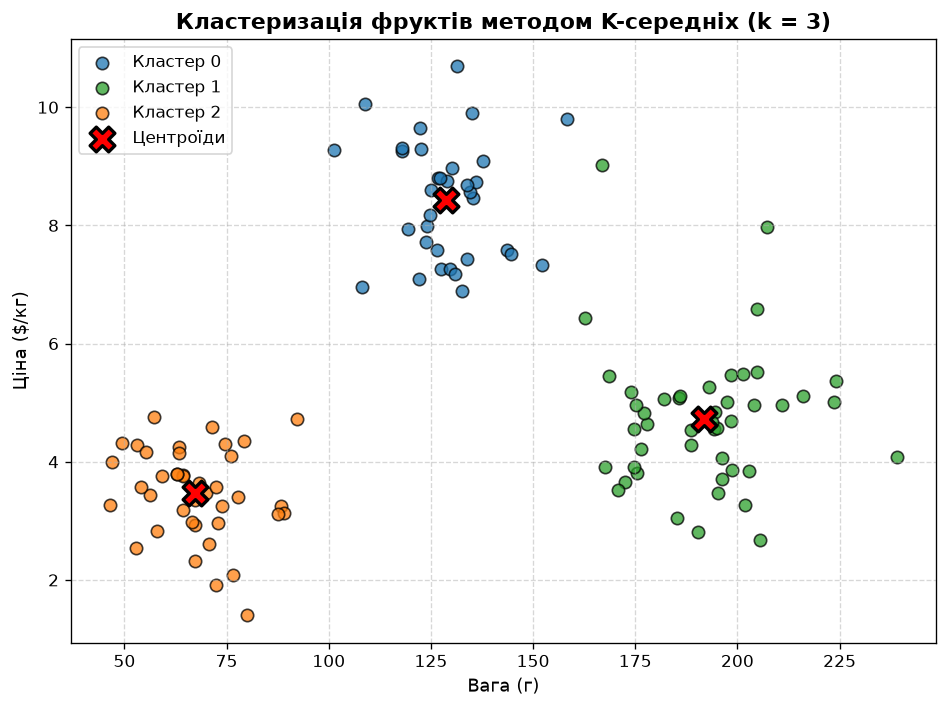

In [2]:
plt.figure(figsize=(8, 6), dpi=120)
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

for i in range(3):
    subset = fruits_data[fruits_data['Кластер'] == i]
    plt.scatter(subset['Вага'], subset['Ціна'], c=colors[i], label=f'Кластер {i}',
                alpha=0.75, edgecolors='k', s=55)

plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', c='red', s=220,
            linewidths=2, edgecolors='black', label='Центроїди', zorder=10)

plt.title('Кластеризація фруктів методом K-середніх (k = 3)', fontsize=13, fontweight='bold')
plt.xlabel('Вага (г)', fontsize=11)
plt.ylabel('Ціна ($/кг)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Оцінка оптимальної кількості кластерів (Метод «ліктя» та силует)
Обчислення WCSS (інерції) та Silhouette Score для значень $k$ від 1 до 10. Точка перегину на графіку WCSS разом із піком коефіцієнта силуету вказують на $k=3$.

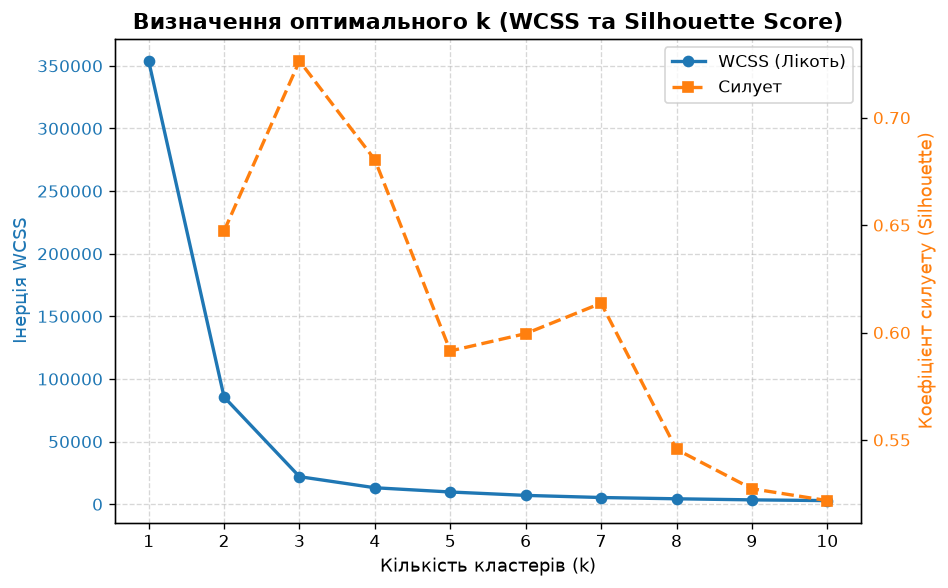

Найвищий коефіцієнт силуету: k = 3 (Score = 0.7264)

In [3]:
k_range = list(range(1, 11))
wcss = []
silhouette_scores = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_fruits)
    wcss.append(km.inertia_)
    if k >= 2:
        silhouette_scores[k] = silhouette_score(X_fruits, labels)

fig, ax1 = plt.subplots(figsize=(8, 5), dpi=120)
color = 'tab:blue'
ax1.set_xlabel('Кількість кластерів (k)', fontsize=11)
ax1.set_ylabel('Інерція WCSS', color=color, fontsize=11)
line1 = ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2, label='WCSS (Лікоть)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Коефіцієнт силуету (Silhouette)', color=color, fontsize=11)
k_sil = list(silhouette_scores.keys())
scores_sil = list(silhouette_scores.values())
line2 = ax2.plot(k_sil, scores_sil, marker='s', color=color, linestyle='--', linewidth=2, label='Силует')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels_leg = [l.get_label() for l in lines]
ax1.legend(lines, labels_leg, loc='upper right')
plt.title('Визначення оптимального k (WCSS та Silhouette Score)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Найвищий коефіцієнт силуету: k = {max(silhouette_scores, key=silhouette_scores.get)} (Score = {max(silhouette_scores.values()):.4f})")

## Частина 2. Ієрархічна агломеративна кластеризація (stocks.csv)
**Мета:** Зчитати часовий ряд котирувань `stocks.csv` (перші 50 спостережень), відкинути колонку дат (зберігши як мітки) та побудувати дендрограму спостережень методом Уорда.

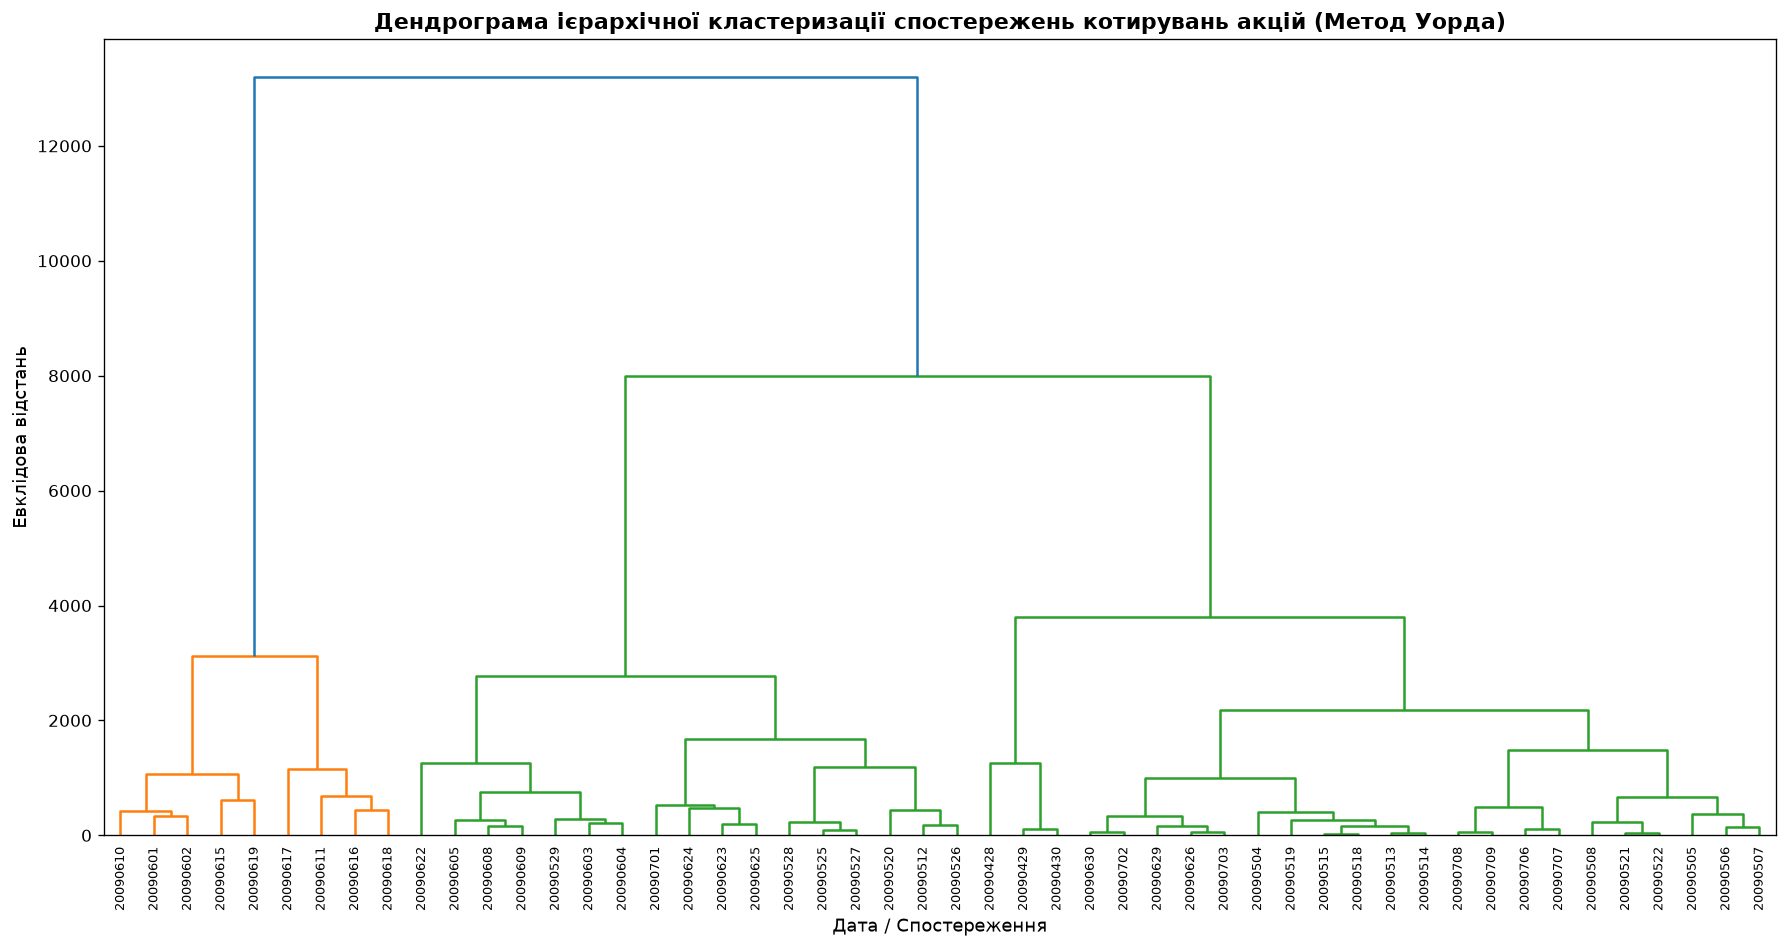

In [4]:
# Завантаження 50 перших спостережень
df_stocks = pd.read_csv('stocks.csv')
df_sub = df_stocks.head(50)
dates = df_sub['DATE'].astype(str).tolist()
X_stocks = df_sub.drop(columns=['DATE'])

# Агломеративна кластеризація спостережень
Z_obs = linkage(X_stocks, method='ward', metric='euclidean')

plt.figure(figsize=(15, 8), dpi=120)
plt.title('Дендрограма ієрархічної кластеризації спостережень котирувань акцій (Метод Уорда)',
          fontsize=13, fontweight='bold')
plt.xlabel('Дата / Спостереження', fontsize=11)
plt.ylabel('Евклідова відстань', fontsize=11)
dendrogram(Z_obs, labels=dates, leaf_rotation=90, leaf_font_size=8)
plt.tight_layout()
plt.show()

## Частина 3. Кластеризація тікерів акцій за динамікою
**Мета:** Стандартизувати показники кожного тікера за допомогою `StandardScaler` (для нівелювання різниці в абсолютному масштабі цін) та кластеризувати самі тікери методом Уорда.

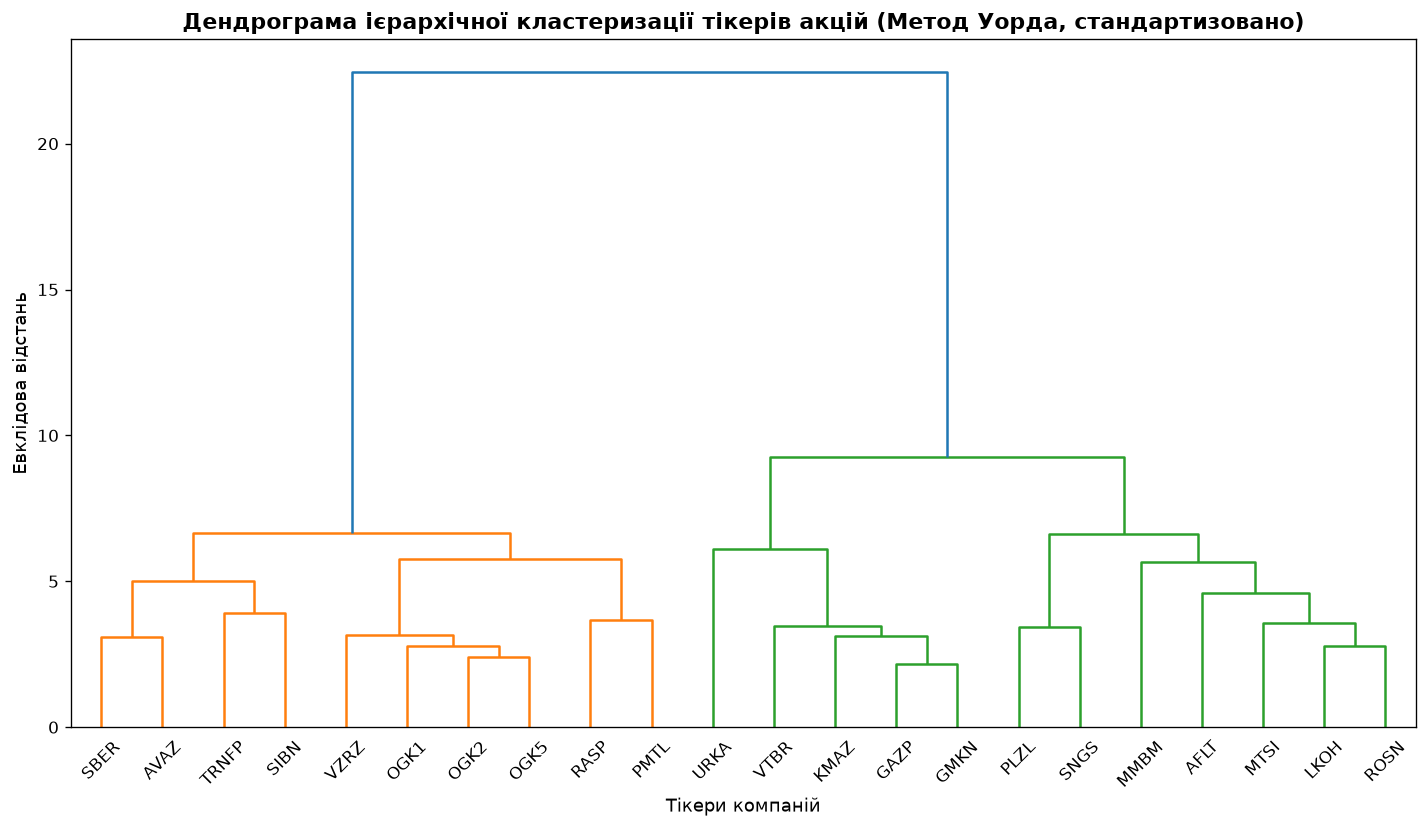

In [5]:
# Стандартизація котирувань кожної компанії для порівняння динаміки
scaler = StandardScaler()
X_stocks_scaled = scaler.fit_transform(X_stocks)

# Транспонуємо: рядки — компанії, стовпці — дні спостереження
tickers = list(X_stocks.columns)
Z_tickers = linkage(X_stocks_scaled.T, method='ward', metric='euclidean')

plt.figure(figsize=(12, 7), dpi=120)
plt.title('Дендрограма ієрархічної кластеризації тікерів акцій (Метод Уорда, стандартизовано)',
          fontsize=13, fontweight='bold')
plt.xlabel('Тікери компаній', fontsize=11)
plt.ylabel('Евклідова відстань', fontsize=11)
dendrogram(Z_tickers, labels=tickers, leaf_rotation=45, leaf_font_size=10)
plt.tight_layout()
plt.show()

## Висновки
На лабораторній роботі було успішно опановано методи k-середніх та агломеративної ієрархічної кластеризації у середовищі Python. Метод ліктя у поєднанні з силуетним аналізом наочно продемонстрував оптимальну кількість кластерів ($k=3$, силует $0.726$). Ієрархічна кластеризація фінансових даних `stocks.csv` дозволила виявити як характерні часові періоди зміни поведінки ринку, так і групи тікерів акцій з високою синхронністю коливань.